In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brain_image.data import batch_load_images


ex_paths = ["data/things-eeg2/imgs/training_images/00001_aardvark/aardvark_01b.jpg"]

imgs = batch_load_images(ex_paths)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

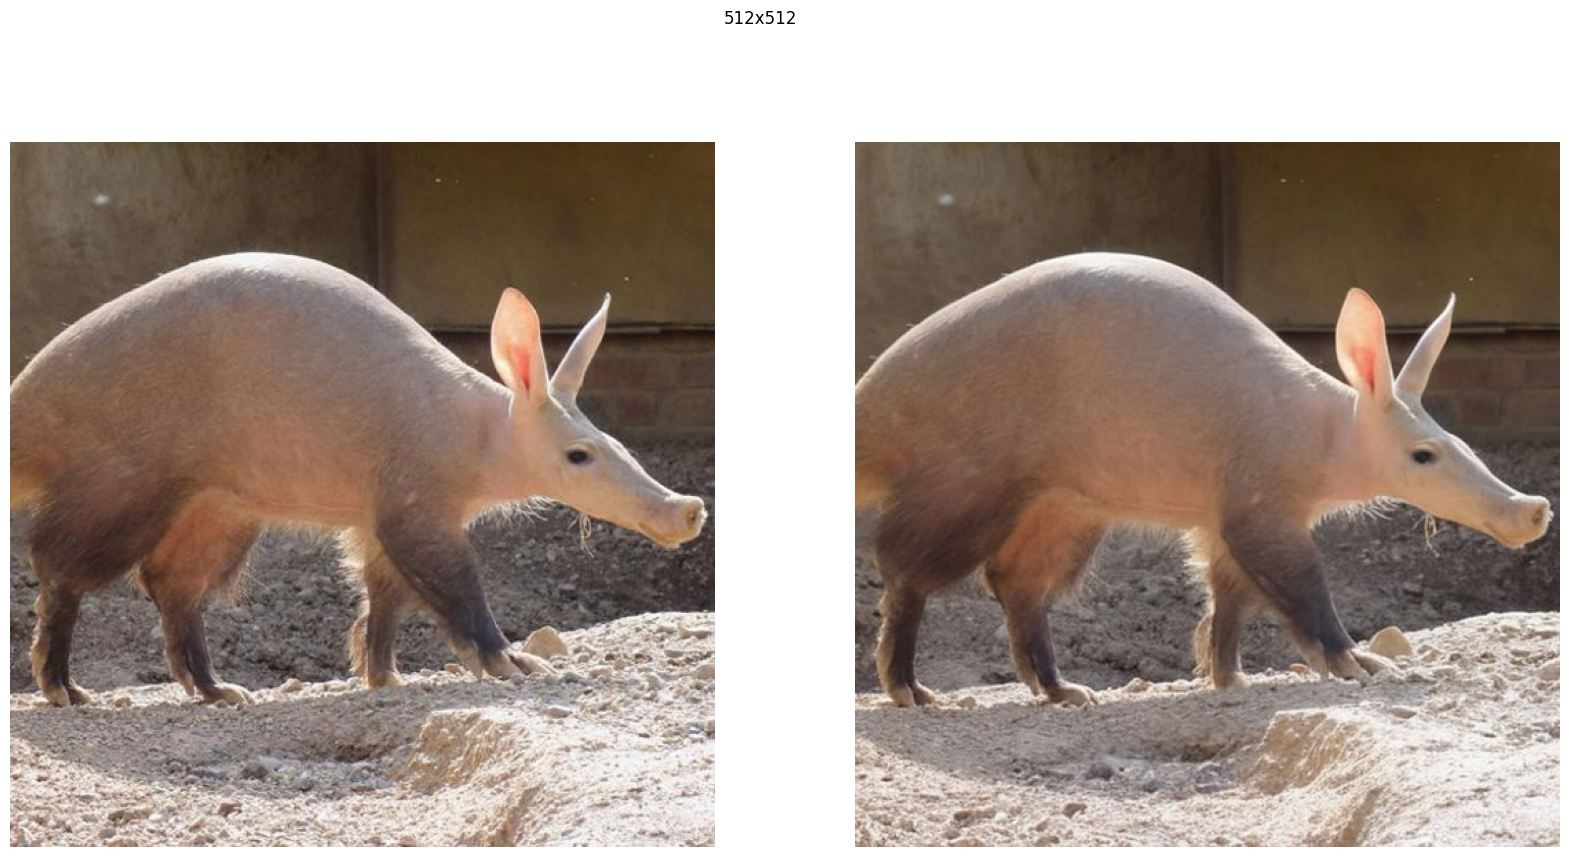

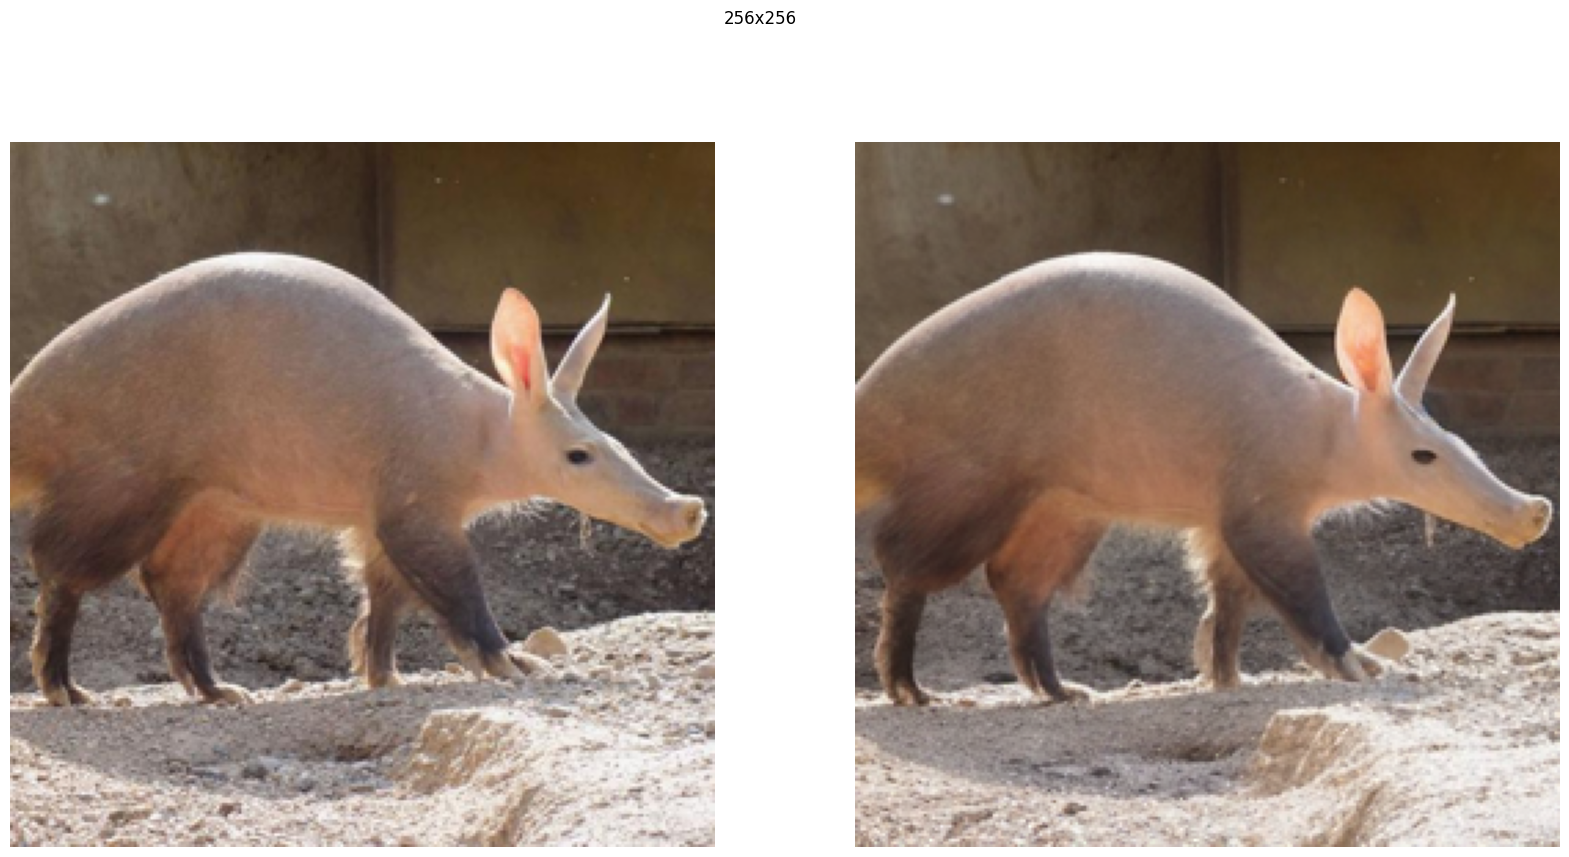

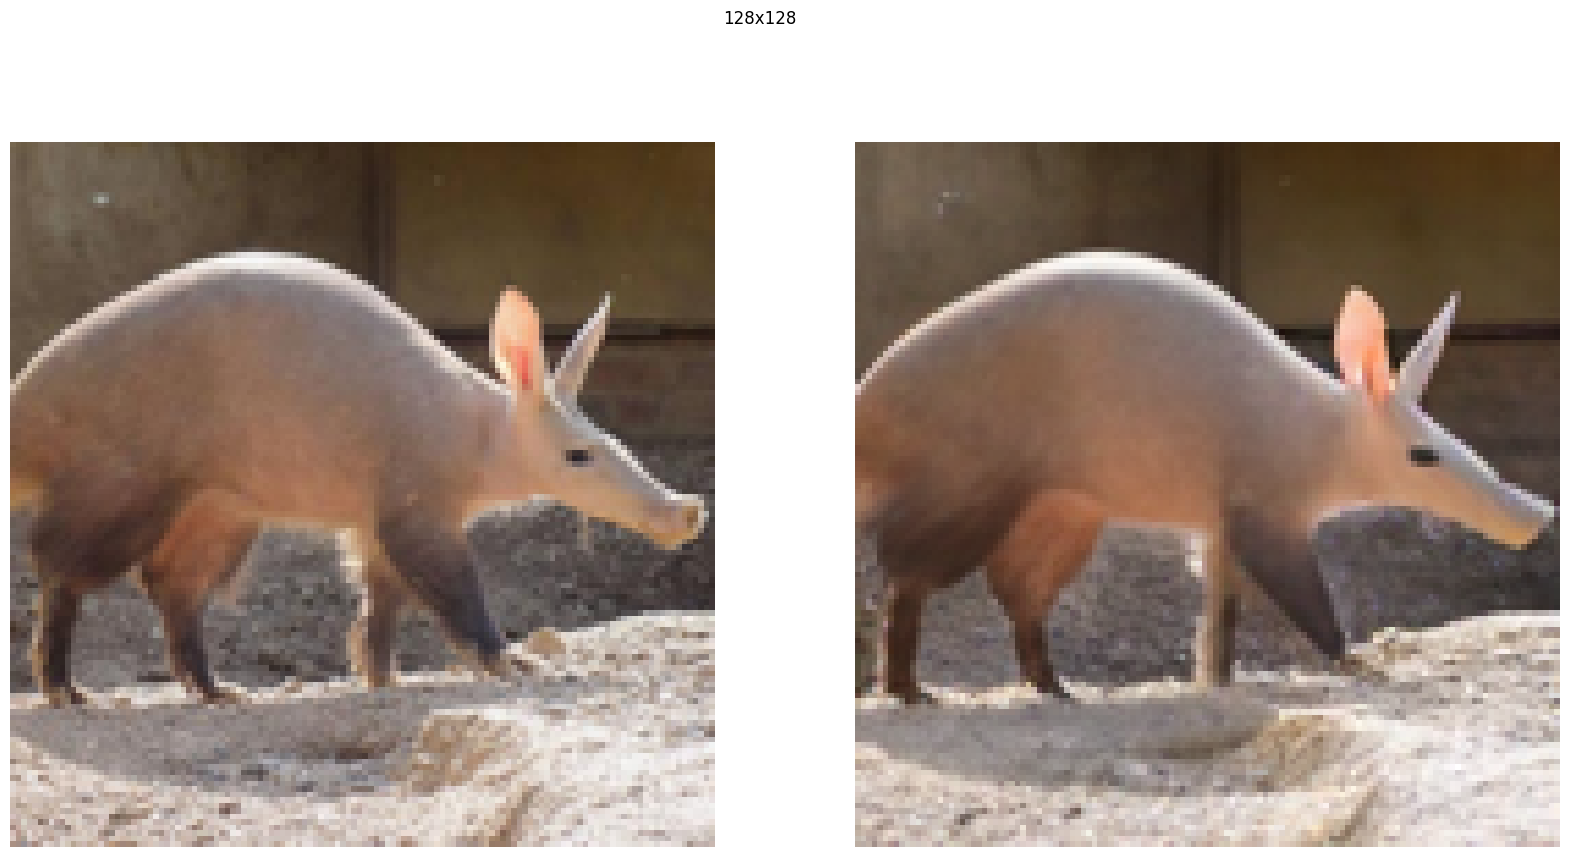

In [3]:
import torch

from brain_image.utils import show_image
from brain_image.model.img_encoder import load_vae_encoder

imgs = imgs.to("cuda")


with torch.no_grad():
    vae_128 = load_vae_encoder("ip_sdxl_turbo", img_width=128).to("cuda")
    imgs_128 = vae_128.preprocess(imgs, skip_processor=True)
    emb_128 = vae_128.encode(imgs)
    imgs_dec_128 = vae_128.decode(emb_128)

    vae_256 = load_vae_encoder("ip_sdxl_turbo", img_width=256).to("cuda")
    imgs_256 = vae_256.preprocess(imgs, skip_processor=True)
    emb_256 = vae_256.encode(imgs)
    imgs_dec_256 = vae_256.decode(emb_256)

    vae_512  = load_vae_encoder("ip_sdxl_turbo", img_width=512).to("cuda")
    imgs_512 = vae_512.preprocess(imgs, skip_processor=True)
    emb_512 = vae_512.encode(imgs)
    imgs_dec_512 = vae_512.decode(emb_512)

show_image(imgs_512, imgs_dec_512, suptitle="512x512")
show_image(imgs_256, imgs_dec_256, suptitle="256x256")
show_image(imgs_128, imgs_dec_128, suptitle="128x128")

In [ ]:
from brain_image.model.loss import LPIPSLoss


print(imgs_128.max(), imgs_128.min(), imgs_dec_128.max(), imgs_dec_128.min())
lpips = LPIPSLoss().to("cuda")
lpips(imgs_128.to("cuda"), imgs_dec_128.to("cuda")), lpips(imgs_128.to("cuda"), imgs_dec_128.to("cuda") + 0.2 * torch.randn_like(imgs_dec_128).to("cuda"))


tensor(1., device='cuda:0') tensor(0.0667, device='cuda:0') tensor(1., device='cuda:0') tensor(0.0468, device='cuda:0')
tensor(1., device='cuda:0') tensor(0.0588, device='cuda:0') tensor(1., device='cuda:0') tensor(0.0308, device='cuda:0')
tensor(1., device='cuda:0') tensor(0.0588, device='cuda:0') tensor(1., device='cuda:0') tensor(0., device='cuda:0')


(tensor(0.2038, device='cuda:0'), tensor(0.6494, device='cuda:0'))

: 